In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cmocean
import matplotlib as mpl
import copy

cm_deep = copy.copy(cmocean.cm.deep)
cm_deep.set_bad('lightgray')
levels = np.linspace(0,6000,61)

In [2]:
DS = '/archive/gold/datasets/'

hgrid = xr.open_dataset(DS+'OM4_025/mosaic.v20170622.unpacked/ocean_hgrid.nc')
topog = xr.open_dataset(DS+'OM4_025/mosaic.v20170622.unpacked/ocean_topog.nc')
mask = xr.open_dataset(DS+'OM4_025/mosaic.v20170622.unpacked/ocean_mask.nc')


In [3]:
mask

<xarray.Dataset> Size: 12MB
Dimensions:  (ny: 1080, nx: 1440)
Dimensions without coordinates: ny, nx
Data variables:
    mask     (ny, nx) float64 12MB ...
Attributes:
    grid_version:  0.2
    code_version:  $Name: siena_201302_z1l $
    history:       ../tools/make_quick_mosaic/make_quick_mosaic --input_mosai...

In [4]:
OM4_grid={}

OM4_grid['Xsuper'] = hgrid.x
OM4_grid['Ysuper'] = hgrid.y
OM4_grid['Xcorner'] = OM4_grid['Xsuper'][::2,::2]
OM4_grid['Ycorner'] = OM4_grid['Ysuper'][::2,::2]
OM4_grid['Xcenter'] = OM4_grid['Xsuper'][1::2,1::2]
OM4_grid['Ycenter'] = OM4_grid['Ysuper'][1::2,1::2]
OM4_grid['Depth'] = topog.depth
OM4_grid['Mask'] = mask.mask


In [5]:
def NaNmask(field,mask):
    field_out = np.copy(field)
    field_out[mask==0.0]=np.NaN
    return field_out

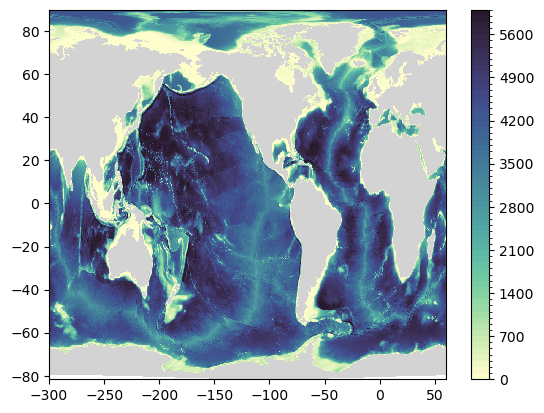

In [6]:
plt.figure()
plt.pcolormesh(OM4_grid['Xcorner'],OM4_grid['Ycorner'],NaNmask(OM4_grid['Depth'].values,OM4_grid['Mask'].values),
               cmap=cm_deep,norm = mpl.colors.BoundaryNorm(levels, ncolors=cm_deep.N, clip=False))
plt.colorbar()


In [7]:
Left_Lon  =-9
Right_Lon = 43
Low_Lat   = 30
Up_Lat    = 48

In [8]:
xi_center = ((OM4_grid['Xcenter'][0,:]-Left_Lon)**2).argmin().values
xf_center = ((OM4_grid['Xcenter'][0,:]-Right_Lon)**2).argmin().values
yi_center = ((OM4_grid['Ycenter'][:,0]-Low_Lat)**2).argmin().values
yf_center = ((OM4_grid['Ycenter'][:,0]-Up_Lat)**2).argmin().values

xi_h = xi_center*2
xf_h = xf_center*2+2
yi_h = yi_center*2
yf_h = yf_center*2+2

print('Corner indices, centers [x,y]\n ',xi_center,xf_center,yi_center,yf_center)
print('Corner indices, corners [x,y]\n ',xi_h,xf_h,yi_h,yf_h)

STR='Corner values, centers [x,y]\n '
STR2='Corner values, corners [x,y]\n '
for xce,xco in [[xi_center,xi_h],
                [xf_center,xf_h],
               ]:
    for yce,yco in [[yi_center,yi_h],
                    [yf_center,yf_h],
                   ]:
        STR += '({:3.2f},{:3.2f})\n'.format(OM4_grid['Xsuper'][yco,xco],OM4_grid['Ysuper'][yco,xco])
        STR2 += '({:3.2f},{:3.2f})\n'.format(OM4_grid['Xcenter'][yce,xce],OM4_grid['Ycenter'][yce,xce])
        
print(STR)
print(STR2)



Corner indices, centers [x,y]
  1161 1370 629 722
Corner indices, corners [x,y]
  2322 2742 1258 1446
Corner values, centers [x,y]
 (-9.75,29.92)
(-9.75,48.01)
(42.75,29.92)
(42.75,48.01)

Corner values, corners [x,y]
 (-9.62,30.02)
(-9.62,47.93)
(42.62,30.02)
(42.62,47.93)



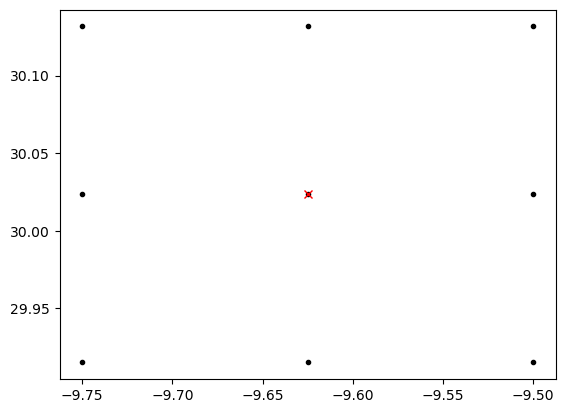

In [9]:
xce = xi_center
yce = yi_center
xco = xi_h
yco = yi_h

plt.figure()
plt.plot(OM4_grid['Xsuper'][yco,xco],OM4_grid['Ysuper'][yco,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco+1,xco],OM4_grid['Ysuper'][yco+1,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco+2,xco],OM4_grid['Ysuper'][yco+2,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco+1],OM4_grid['Ysuper'][yco,xco+1],'k.')
plt.plot(OM4_grid['Xsuper'][yco+1,xco+1],OM4_grid['Ysuper'][yco+1,xco+1],'k.')
plt.plot(OM4_grid['Xsuper'][yco+2,xco+1],OM4_grid['Ysuper'][yco+2,xco+1],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco+2],OM4_grid['Ysuper'][yco,xco+2],'k.')
plt.plot(OM4_grid['Xsuper'][yco+1,xco+2],OM4_grid['Ysuper'][yco+1,xco+2],'k.')
plt.plot(OM4_grid['Xsuper'][yco+2,xco+2],OM4_grid['Ysuper'][yco+2,xco+2],'k.')
plt.plot(OM4_grid['Xcenter'][yce,xce],OM4_grid['Ycenter'][yce,xce],'rx')
        

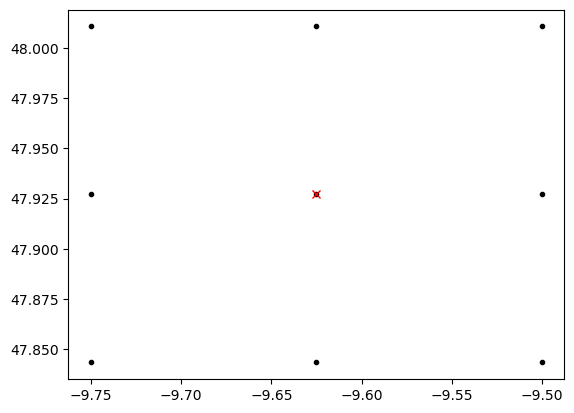

In [10]:
xce = xi_center
yce = yf_center
xco = xi_h
yco = yf_h

plt.figure()
plt.plot(OM4_grid['Xsuper'][yco,xco],OM4_grid['Ysuper'][yco,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco-1,xco],OM4_grid['Ysuper'][yco-1,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco-2,xco],OM4_grid['Ysuper'][yco-2,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco+1],OM4_grid['Ysuper'][yco,xco+1],'k.')
plt.plot(OM4_grid['Xsuper'][yco-1,xco+1],OM4_grid['Ysuper'][yco-1,xco+1],'k.')
plt.plot(OM4_grid['Xsuper'][yco-2,xco+1],OM4_grid['Ysuper'][yco-2,xco+1],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco+2],OM4_grid['Ysuper'][yco,xco+2],'k.')
plt.plot(OM4_grid['Xsuper'][yco-1,xco+2],OM4_grid['Ysuper'][yco-1,xco+2],'k.')
plt.plot(OM4_grid['Xsuper'][yco-2,xco+2],OM4_grid['Ysuper'][yco-2,xco+2],'k.')
plt.plot(OM4_grid['Xcenter'][yce,xce],OM4_grid['Ycenter'][yce,xce],'rx')
        

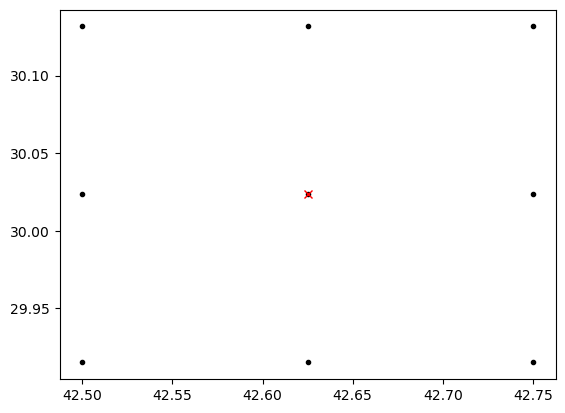

In [11]:
xce = xf_center
yce = yi_center
xco = xf_h
yco = yi_h

plt.figure()
plt.plot(OM4_grid['Xsuper'][yco,xco],OM4_grid['Ysuper'][yco,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco+1,xco],OM4_grid['Ysuper'][yco+1,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco+2,xco],OM4_grid['Ysuper'][yco+2,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco-1],OM4_grid['Ysuper'][yco,xco-1],'k.')
plt.plot(OM4_grid['Xsuper'][yco+1,xco-1],OM4_grid['Ysuper'][yco+1,xco-1],'k.')
plt.plot(OM4_grid['Xsuper'][yco+2,xco-1],OM4_grid['Ysuper'][yco+2,xco-1],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco-2],OM4_grid['Ysuper'][yco,xco-2],'k.')
plt.plot(OM4_grid['Xsuper'][yco+1,xco-2],OM4_grid['Ysuper'][yco+1,xco-2],'k.')
plt.plot(OM4_grid['Xsuper'][yco+2,xco-2],OM4_grid['Ysuper'][yco+2,xco-2],'k.')
plt.plot(OM4_grid['Xcenter'][yce,xce],OM4_grid['Ycenter'][yce,xce],'rx')
        

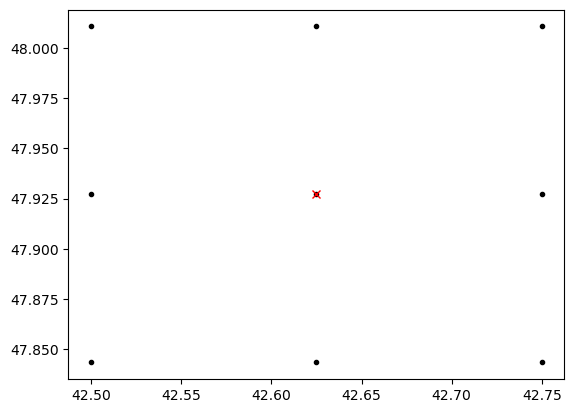

In [12]:
xce = xf_center
yce = yf_center
xco = xf_h
yco = yf_h

plt.figure()
plt.plot(OM4_grid['Xsuper'][yco,xco],OM4_grid['Ysuper'][yco,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco-1,xco],OM4_grid['Ysuper'][yco-1,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco-2,xco],OM4_grid['Ysuper'][yco-2,xco],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco-1],OM4_grid['Ysuper'][yco,xco-1],'k.')
plt.plot(OM4_grid['Xsuper'][yco-1,xco-1],OM4_grid['Ysuper'][yco-1,xco-1],'k.')
plt.plot(OM4_grid['Xsuper'][yco-2,xco-1],OM4_grid['Ysuper'][yco-2,xco-1],'k.')
plt.plot(OM4_grid['Xsuper'][yco,xco-2],OM4_grid['Ysuper'][yco,xco-2],'k.')
plt.plot(OM4_grid['Xsuper'][yco-1,xco-2],OM4_grid['Ysuper'][yco-1,xco-2],'k.')
plt.plot(OM4_grid['Xsuper'][yco-2,xco-2],OM4_grid['Ysuper'][yco-2,xco-2],'k.')
plt.plot(OM4_grid['Xcenter'][yce,xce],OM4_grid['Ycenter'][yce,xce],'rx')
        

In [13]:
Med_grid = {}

Med_grid['Xsuper'] = hgrid.x.values[yi_h:yf_h+1,xi_h:xf_h+1]
Med_grid['Ysuper'] = hgrid.y.values[yi_h:yf_h+1,xi_h:xf_h+1]
Med_grid['Xcorners'] = Med_grid['Xsuper'][::2,::2]
Med_grid['Ycorners'] = Med_grid['Ysuper'][::2,::2]
Med_grid['Xcenters'] = Med_grid['Xsuper'][1::2,1::2]
Med_grid['Ycenters'] = Med_grid['Ysuper'][1::2,1::2]
Med_grid['Depth'] = topog.depth.values[yi_center:yf_center+1,xi_center:xf_center+1]
Med_grid['Mask'] = mask.mask.values[yi_center:yf_center+1,xi_center:xf_center+1]

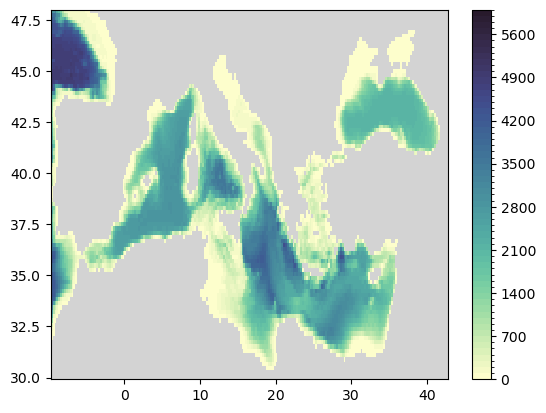

In [14]:
plt.figure()
plt.pcolormesh(Med_grid['Xcorners'],Med_grid['Ycorners'],NaNmask(Med_grid['Depth'],Med_grid['Mask']),
               cmap=cm_deep,norm = mpl.colors.BoundaryNorm(levels, ncolors=cm_deep.N, clip=False))
plt.colorbar()


In [15]:
hgrid

<xarray.Dataset> Size: 299MB
Dimensions:   (nyp: 2161, nxp: 2881, ny: 2160, nx: 2880)
Dimensions without coordinates: nyp, nxp, ny, nx
Data variables:
    angle_dx  (nyp, nxp) float64 50MB ...
    area      (ny, nx) float64 50MB ...
    dx        (nyp, nx) float64 50MB ...
    dy        (ny, nxp) float64 50MB ...
    tile      |S255 255B ...
    x         (nyp, nxp) float64 50MB -299.8 -299.7 -299.6 ... 60.0 60.0 60.0
    y         (nyp, nxp) float64 50MB -79.84 -79.84 -79.84 ... 64.17 64.11 64.06

In [16]:
Med_hgrid = xr.Dataset()
Med_hgrid['angle_dx']=(('nyp','nxp'),hgrid.angle_dx.values[yi_h:yf_h+1,xi_h:xf_h+1])
Med_hgrid['area']=(('ny','nx'),hgrid.area.values[yi_h:yf_h,xi_h:xf_h])
Med_hgrid['dx']=(('nyp','nx'),hgrid.dx.values[yi_h:yf_h+1,xi_h:xf_h])
Med_hgrid['dy']=(('ny','nxp'),hgrid.dy.values[yi_h:yf_h,xi_h:xf_h+1])
Med_hgrid['tile']=hgrid.tile.values
Med_hgrid['x']=(('nyp','nxp'),hgrid.x.values[yi_h:yf_h+1,xi_h:xf_h+1])
Med_hgrid['y']=(('nyp','nxp'),hgrid.y.values[yi_h:yf_h+1,xi_h:xf_h+1])

In [17]:
Med_hgrid

<xarray.Dataset> Size: 4MB
Dimensions:   (nyp: 189, nxp: 421, ny: 188, nx: 420)
Dimensions without coordinates: nyp, nxp, ny, nx
Data variables:
    angle_dx  (nyp, nxp) float64 637kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    area      (ny, nx) float64 632kB 1.454e+08 1.454e+08 ... 8.686e+07 8.686e+07
    dx        (nyp, nx) float64 635kB 1.206e+04 1.206e+04 ... 9.309e+03
    dy        (ny, nxp) float64 633kB 1.205e+04 1.205e+04 ... 9.316e+03
    tile      |S255 255B b'tile1'
    x         (nyp, nxp) float64 637kB -9.75 -9.625 -9.5 ... 42.5 42.62 42.75
    y         (nyp, nxp) float64 637kB 29.92 29.92 29.92 ... 48.01 48.01 48.01

In [18]:
mask

<xarray.Dataset> Size: 12MB
Dimensions:  (ny: 1080, nx: 1440)
Dimensions without coordinates: ny, nx
Data variables:
    mask     (ny, nx) float64 12MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    grid_version:  0.2
    code_version:  $Name: siena_201302_z1l $
    history:       ../tools/make_quick_mosaic/make_quick_mosaic --input_mosai...

In [19]:
Med_mask = xr.Dataset()
Med_mask['mask']=(('ny','nx'),mask.mask.values[yi_center:yf_center+1,xi_center:xf_center+1])

In [20]:
Med_mask

<xarray.Dataset> Size: 158kB
Dimensions:  (ny: 94, nx: 210)
Dimensions without coordinates: ny, nx
Data variables:
    mask     (ny, nx) float64 158kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [21]:
topog

<xarray.Dataset> Size: 25MB
Dimensions:        (nEdits: 95, ny: 1080, nx: 1440)
Dimensions without coordinates: nEdits, ny, nx
Data variables:
    jEdit          (nEdits) int32 380B ...
    depth          (ny, nx) float32 6MB -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0
    h2             (ny, nx) float32 6MB ...
    iEdit          (nEdits) int32 380B ...
    modified_mask  (ny, nx) float32 6MB ...
    wet            (ny, nx) float32 6MB ...
    zEdit          (nEdits) float32 380B ...

In [22]:
Med_topog = xr.Dataset()
Med_topog['depth'] = (('ny','nx'),topog.depth.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_topog['h2'] = (('ny','nx'),topog.h2.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_topog['wet'] = (('ny','nx'),topog.wet.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_topog['tile'] = (('ntiles'),['1'])




In [23]:
Med_topog

<xarray.Dataset> Size: 237kB
Dimensions:  (ny: 94, nx: 210, ntiles: 1)
Dimensions without coordinates: ny, nx, ntiles
Data variables:
    depth    (ny, nx) float32 79kB -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0 -0.0
    h2       (ny, nx) float32 79kB 1.75e+03 7.274e+03 2.641e+04 ... 63.35 7.559
    wet      (ny, nx) float32 79kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    tile     (ntiles) <U1 4B '1'

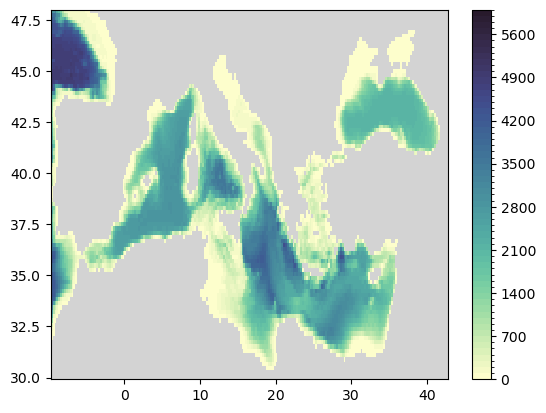

In [24]:
plt.figure()
plt.pcolormesh(Med_hgrid.x[::2,::2],Med_hgrid.y[::2,::2],NaNmask(Med_topog['depth'].values,Med_mask['mask'].values),
               cmap=cm_deep,norm = mpl.colors.BoundaryNorm(levels, ncolors=cm_deep.N, clip=False))
plt.colorbar()


In [25]:
Med_topog.to_netcdf('./Med_topog.nc')
#Med_mask.to_netcdf('./Med_mask.nc') !This is done by the exchange grid!
Med_hgrid.to_netcdf('./Med_hgrid.nc')

In [26]:
import subprocess

In [27]:
subprocess.run(["BuildExchangeGrid.csh"]);

Loading fre/bronx-21
  Loading requirement: zlib/1.2.13 hdf5/1.14.1-2 netcdf-c/4.9.2 nccmp/1.9.0.1
    gsl/2.7.1 udunits/2.2.28 nco/5.1.5 netcdf-fortran/4.6.0 fre-nctools/2024.02
    perlbrew/5.38.2 gcp/2.3 hsm/1.3.0
cp: './ocean_mosaic.nc' and 'ocean_mosaic.nc' are the same file
cp: './Med_hgrid.nc' and 'Med_hgrid.nc' are the same file


i=0, xb1=-9.7500000000, xb2=42.7500000000, dx=-127.5000000000
NOTE from make_solo_mosaic: there are 0 contacts (align-contact)
congratulation: You have successfully run make_solo_mosaic
cp ./Med_hgrid.nc Med_hgrid.nc 

NOTE from make_coupler_mosaic: the ocean land/sea mask will be determined by field depth from file Med_topog.nc
mosaic_file is grid_spec.nc

***** Congratulation! You have successfully run make_quick_mosaic


In [82]:
seawifs = xr.open_dataset('../INPUT/seawifs-clim-1997-2010.1440x1080.v20180328.nc')
salt_restore = xr.open_dataset('../../OM4_025.JRA/INPUT/salt_restore_JRA.1440x1080.v20190706.nc')
JRA_friver = xr.open_dataset('../../OM4_025.JRA/INPUT/JRA_friver.nc')
JRA_licalvf = xr.open_dataset('../../OM4_025.JRA/INPUT/JRA_licalvf.nc')
geothermal = xr.open_dataset('../../OM4_025.JRA/INPUT/geothermal_davies2013_v1.nc')
tideamp = xr.open_dataset('../../OM4_025.JRA/INPUT/tidal_amplitude.v20140616.nc')

In [29]:
seawifs

<xarray.Dataset> Size: 112MB
Dimensions:   (i: 1440, j: 1080, IQ: 1441, JQ: 1081, time: 12)
Coordinates:
  * i         (i) float32 6kB 0.5 1.5 2.5 3.5 ... 1.438e+03 1.438e+03 1.44e+03
  * j         (j) float32 4kB 0.5 1.5 2.5 3.5 ... 1.078e+03 1.078e+03 1.08e+03
  * IQ        (IQ) float32 6kB 0.0 1.0 2.0 3.0 ... 1.438e+03 1.439e+03 1.44e+03
  * JQ        (JQ) float32 4kB 0.0 1.0 2.0 3.0 ... 1.078e+03 1.079e+03 1.08e+03
  * time      (time) object 96B 0001-01-16 12:00:00 ... 0001-12-16 12:00:00
    lon       (j, i) float32 6MB ...
    lat       (j, i) float32 6MB ...
Data variables:
    lon_crnr  (JQ, IQ) float32 6MB ...
    lat_crnr  (JQ, IQ) float32 6MB ...
    area      (j, i) float64 12MB ...
    chlor_a   (time, j, i) float32 75MB ...

In [30]:
Med_seawifs = xr.Dataset()
Med_seawifs['i'] = (('i'),np.arange(0.5,Med_topog.nx.size))
Med_seawifs['j'] = (('j'),np.arange(0.5,Med_topog.ny.size))
Med_seawifs['IQ'] = (('IQ'),range(Med_topog.nx.size+1))
Med_seawifs['JQ'] = (('JQ'),range(Med_topog.ny.size+1))
Med_seawifs['time'] = (('time'),seawifs.time.values)
Med_seawifs['lon'] = (('j','i'),seawifs.lon.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_seawifs['lat'] = (('j','i'),seawifs.lat.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_seawifs['lon_crnr'] = (('JQ','IQ'),seawifs.lon_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_seawifs['lat_crnr'] = (('JQ','IQ'),seawifs.lat_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_seawifs['area'] = (('j','i'),seawifs.area.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_seawifs['chlor_a'] = (('time','j','i'),seawifs.chlor_a.values[:,yi_center:yf_center+1,xi_center:xf_center+1])


In [31]:
Med_seawifs.to_netcdf('./Med_seawifs.nc',unlimited_dims='time')
#  ncatted -a cartesian_axis,i,a,c,"X" Med_seawifs.nc
# ncatted -a cartesian_axis,j,a,c,"Y" Med_seawifs.nc
# ncatted -a cartesian_axis,time,a,c,"T" Med_seawifs.nc


In [32]:
salt_restore

<xarray.Dataset> Size: 112MB
Dimensions:   (i: 1440, j: 1080, IQ: 1441, JQ: 1081, time: 12)
Coordinates:
  * i         (i) float32 6kB 0.5 1.5 2.5 3.5 ... 1.438e+03 1.438e+03 1.44e+03
  * j         (j) float32 4kB 0.5 1.5 2.5 3.5 ... 1.078e+03 1.078e+03 1.08e+03
  * IQ        (IQ) float32 6kB 0.0 1.0 2.0 3.0 ... 1.438e+03 1.439e+03 1.44e+03
  * JQ        (JQ) float32 4kB 0.0 1.0 2.0 3.0 ... 1.078e+03 1.079e+03 1.08e+03
  * time      (time) object 96B 1900-01-16 00:00:00 ... 1900-12-16 00:00:00
    lon       (j, i) float32 6MB ...
    lat       (j, i) float32 6MB ...
Data variables:
    lon_crnr  (JQ, IQ) float32 6MB ...
    lat_crnr  (JQ, IQ) float32 6MB ...
    area      (j, i) float64 12MB ...
    sos       (time, j, i) float32 75MB ...

In [33]:
Med_salt_restore = xr.Dataset()
Med_salt_restore['i'] = (('i'),np.arange(0.5,Med_topog.nx.size))
Med_salt_restore['j'] = (('j'),np.arange(0.5,Med_topog.ny.size))
Med_salt_restore['IQ'] = (('IQ'),range(Med_topog.nx.size+1))
Med_salt_restore['JQ'] = (('JQ'),range(Med_topog.ny.size+1))
Med_salt_restore['time'] = (('time'),salt_restore.time.values)
Med_salt_restore['lon'] = (('j','i'),salt_restore.lon.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_salt_restore['lat'] = (('j','i'),salt_restore.lat.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_salt_restore['lon_crnr'] = (('JQ','IQ'),salt_restore.lon_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_salt_restore['lat_crnr'] = (('JQ','IQ'),salt_restore.lat_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_salt_restore['area'] = (('j','i'),salt_restore.area.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_salt_restore['sos'] = (('time','j','i'),salt_restore.sos.values[:,yi_center:yf_center+1,xi_center:xf_center+1])


In [34]:
Med_salt_restore.to_netcdf('./Med_salt_restore.nc',unlimited_dims='time')
#ncatted -a modulo,time,o,c," " Med_seawifs.nc 

In [35]:
JRA_friver

<xarray.Dataset> Size: 2GB
Dimensions:   (i: 1440, j: 1080, IQ: 1441, JQ: 1081, time: 367)
Coordinates:
  * i         (i) float32 6kB 0.5 1.5 2.5 3.5 ... 1.438e+03 1.438e+03 1.44e+03
  * j         (j) float32 4kB 0.5 1.5 2.5 3.5 ... 1.078e+03 1.078e+03 1.08e+03
  * IQ        (IQ) float32 6kB 0.0 1.0 2.0 3.0 ... 1.438e+03 1.439e+03 1.44e+03
  * JQ        (JQ) float32 4kB 0.0 1.0 2.0 3.0 ... 1.078e+03 1.079e+03 1.08e+03
  * time      (time) datetime64[ns] 3kB 1958-01-01 ... 1959-01-01T12:00:00
    lon       (j, i) float32 6MB ...
    lat       (j, i) float32 6MB ...
Data variables:
    lon_crnr  (JQ, IQ) float32 6MB ...
    lat_crnr  (JQ, IQ) float32 6MB ...
    area      (j, i) float64 12MB ...
    friver    (time, j, i) float32 2GB ...
Attributes: (12/37)
    Conventions:         CF-1.7 CMIP-6.2
    activity_id:         input4MIPs
    cell_measures:       area: areacello
    comment:             Based on JRA-55 reanalysis (1958-01 to 2019-01)
    contact:             Hiroyuki Tsujino (htsujino@mri-jma.go.jp)
    creation_date:       2019-03-08T11:49:26Z
    ...                  ...
    title:               MRI JRA55-do 1.4.0 dataset prepared for input4MIPs
    tracking_id:         hdl:21.14100/fd7d7d42-7c52-4b95-8dcc-cf468e42aa23
    variable_id:         friver
    license:             OMIP boundary condition data produced by MRI is lice...
    cmor_version:        3.4.0
    regrid_note:         Regridded with regrid_runoff.py

In [36]:
Med_JRA_friver = xr.Dataset()
Med_JRA_friver['i'] = (('i'),np.arange(0.5,Med_topog.nx.size))
Med_JRA_friver['j'] = (('j'),np.arange(0.5,Med_topog.ny.size))
Med_JRA_friver['IQ'] = (('IQ'),range(Med_topog.nx.size+1))
Med_JRA_friver['JQ'] = (('JQ'),range(Med_topog.ny.size+1))
Med_JRA_friver['time'] = (('time'),JRA_friver.time.values)
Med_JRA_friver['lon'] = (('j','i'),JRA_friver.lon.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_JRA_friver['lat'] = (('j','i'),JRA_friver.lat.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_JRA_friver['lon_crnr'] = (('JQ','IQ'),JRA_friver.lon_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_JRA_friver['lat_crnr'] = (('JQ','IQ'),JRA_friver.lat_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_JRA_friver['area'] = (('j','i'),JRA_friver.area.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_JRA_friver['friver'] = (('time','j','i'),JRA_friver.friver.values[:,yi_center:yf_center+1,xi_center:xf_center+1])


In [37]:
Med_JRA_friver.to_netcdf('./Med_JRA_friver.nc',unlimited_dims='time')
#ncatted -a calendar,time,o,c,"gregorian" Med_JRA_licalvf.nc

In [38]:
JRA_licalvf

<xarray.Dataset> Size: 2GB
Dimensions:   (i: 1440, j: 1080, IQ: 1441, JQ: 1081, time: 367)
Coordinates:
  * i         (i) float32 6kB 0.5 1.5 2.5 3.5 ... 1.438e+03 1.438e+03 1.44e+03
  * j         (j) float32 4kB 0.5 1.5 2.5 3.5 ... 1.078e+03 1.078e+03 1.08e+03
  * IQ        (IQ) float32 6kB 0.0 1.0 2.0 3.0 ... 1.438e+03 1.439e+03 1.44e+03
  * JQ        (JQ) float32 4kB 0.0 1.0 2.0 3.0 ... 1.078e+03 1.079e+03 1.08e+03
  * time      (time) datetime64[ns] 3kB 1958-01-01 ... 1959-01-01T12:00:00
    lon       (j, i) float32 6MB ...
    lat       (j, i) float32 6MB ...
Data variables:
    lon_crnr  (JQ, IQ) float32 6MB ...
    lat_crnr  (JQ, IQ) float32 6MB ...
    area      (j, i) float64 12MB ...
    licalvf   (time, j, i) float32 2GB ...
Attributes: (12/37)
    Conventions:         CF-1.7 CMIP-6.2
    activity_id:         input4MIPs
    cell_measures:       area: areacello
    comment:             Based on JRA-55 reanalysis (1958-01 to 2019-01)
    contact:             Hiroyuki Tsujino (htsujino@mri-jma.go.jp)
    creation_date:       2019-03-07T08:00:57Z
    ...                  ...
    title:               MRI JRA55-do 1.4.0 dataset prepared for input4MIPs
    tracking_id:         hdl:21.14100/591ce421-d6ca-4bea-a05f-7aae929b15ab
    variable_id:         licalvf
    license:             OMIP boundary condition data produced by MRI is lice...
    cmor_version:        3.4.0
    regrid_note:         Regridded with regrid_runoff.py

In [39]:
Med_JRA_licalvf = xr.Dataset()
Med_JRA_licalvf['i'] = (('i'),np.arange(0.5,Med_topog.nx.size))
Med_JRA_licalvf['j'] = (('j'),np.arange(0.5,Med_topog.ny.size))
Med_JRA_licalvf['IQ'] = (('IQ'),range(Med_topog.nx.size+1))
Med_JRA_licalvf['JQ'] = (('JQ'),range(Med_topog.ny.size+1))
Med_JRA_licalvf['time'] = (('time'),JRA_licalvf.time.values)
Med_JRA_licalvf['lon'] = (('j','i'),JRA_licalvf.lon.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_JRA_licalvf['lat'] = (('j','i'),JRA_licalvf.lat.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_JRA_licalvf['lon_crnr'] = (('JQ','IQ'),JRA_licalvf.lon_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_JRA_licalvf['lat_crnr'] = (('JQ','IQ'),JRA_licalvf.lat_crnr.values[yi_center:yf_center+2,xi_center:xf_center+2])
Med_JRA_licalvf['area'] = (('j','i'),JRA_licalvf.area.values[yi_center:yf_center+1,xi_center:xf_center+1])
Med_JRA_licalvf['licalvf'] = (('time','j','i'),JRA_licalvf.licalvf.values[:,yi_center:yf_center+1,xi_center:xf_center+1])


In [40]:
Med_JRA_licalvf.to_netcdf('./Med_JRA_licalvf.nc',unlimited_dims='time')

In [78]:
geothermal

<xarray.Dataset> Size: 6MB
Dimensions:        (j: 1080, i: 1440)
Coordinates:
  * j              (j) float32 4kB 0.5 1.5 2.5 ... 1.078e+03 1.078e+03 1.08e+03
  * i              (i) float32 6kB 0.5 1.5 2.5 ... 1.438e+03 1.438e+03 1.44e+03
Data variables:
    geothermal_hf  (j, i) float32 6MB ...
Attributes:
    title:          Geothermal heat flow from Davies, 2013, re-gridded to OM4...
    reference:      Davies, J. Huw, 2013: Global map of solid Earth surface h...
    reference_url:  http://dx.doi.org/10.1002/ggge.20271

In [80]:
Med_geothermal = xr.Dataset()
Med_geothermal['i'] = (('i'),np.arange(0.5,Med_topog.nx.size))
Med_geothermal['j'] = (('j'),np.arange(0.5,Med_topog.ny.size))
Med_geothermal['geothermal_hf'] = (('j','i'),geothermal.geothermal_hf.values[yi_center:yf_center+1,xi_center:xf_center+1])


In [81]:
Med_geothermal.to_netcdf('./Med_geothermal.nc')

In [83]:
tideamp

<xarray.Dataset> Size: 6MB
Dimensions:  (ny: 1080, nx: 1440)
Coordinates:
  * ny       (ny) float64 9kB -80.39 -80.31 -80.23 -80.15 ... 89.73 89.84 89.94
  * nx       (nx) float64 12kB -299.7 -299.5 -299.2 -299.0 ... 59.54 59.79 60.04
Data variables:
    tideamp  (ny, nx) float32 6MB ...

In [85]:
Med_tideamp = xr.Dataset()
Med_tideamp['ny'] = (('ny'),tideamp.ny.values[yi_center:yf_center+1])
Med_tideamp['nx'] = (('nx'),tideamp.nx.values[xi_center:xf_center+1])
Med_tideamp['tideamp'] = (('ny','nx'),tideamp.tideamp.values[yi_center:yf_center+1,xi_center:xf_center+1])


In [86]:
Med_tideamp.to_netcdf('./Med_tideamp.nc')